In [1]:
!uv pip install transformers
!uv pip install albumentations
!uv pip install segmentation-models-pytorch

Using Python 3.12.12 environment at: /usr
Audited 1 package in 325ms
Using Python 3.12.12 environment at: /usr
Audited 1 package in 141ms
Using Python 3.12.12 environment at: /usr
Resolved 54 packages in 435ms                                        
Prepared 1 package in 54ms                                               
Installed 1 package in 6ms-pytorch==0.5.0                   
 + segmentation-models-pytorch==0.5.0


In [2]:
import os
import cv2
import torch
import numpy as np
import pandas as pd

from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

from transformers import SegformerForSemanticSegmentation
from transformers import SegformerImageProcessor

from tqdm import tqdm

In [3]:
DATA_PATH = "/kaggle/input/datasets/farzadnekouei/pothole-image-segmentation-dataset/Pothole_Segmentation_YOLOv8"

TRAIN_IMG = f"{DATA_PATH}/train/images"
TRAIN_LBL = f"{DATA_PATH}/train/labels"

VAL_IMG = f"{DATA_PATH}/valid/images"
VAL_LBL = f"{DATA_PATH}/valid/labels"

In [4]:
def yolo_to_mask(label_path, img_shape):

    h, w = img_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    if not os.path.exists(label_path):
        return mask

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:
        parts = list(map(float, line.strip().split()))

        cls = int(parts[0])
        coords = parts[1:]

        pts = []
        for i in range(0, len(coords), 2):
            x = int(coords[i] * w)
            y = int(coords[i+1] * h)
            pts.append([x, y])

        pts = np.array(pts, dtype=np.int32)

        cv2.fillPoly(mask, [pts], 1)

    return mask

In [5]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose(

[
    A.Resize(512,512),

    # geometric transforms
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=10,
        p=0.5
    ),

    # brightness changes (important for road scenes)
    A.RandomBrightnessContrast(
        brightness_limit=0.35,
        contrast_limit=0.35,
        p=0.6
    ),

    # simulate shadows on road
    A.RandomShadow(p=0.3),

    # simulate camera blur
    A.MotionBlur(blur_limit=5, p=0.2),

    # noise from camera sensor
    A.GaussNoise(p=0.2),

    # normalization
    A.Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225)
    ),

    ToTensorV2()
],
additional_targets={"mask":"mask"}
)

val_transform = A.Compose(
[
    A.Resize(512,512),

    A.Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225)
    ),

    ToTensorV2()
],
additional_targets={"mask":"mask"}
)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [7]:
import os
import cv2
import torch
from torch.utils.data import Dataset

class PotholeDataset(Dataset):

    def __init__(self, img_dir, lbl_dir, transforms=None):

        self.img_dir = img_dir
        self.lbl_dir = lbl_dir
        self.transforms = transforms

        # keep only valid image files
        self.images = sorted([
            f for f in os.listdir(img_dir)
            if f.endswith(".jpg") or f.endswith(".png") or f.endswith(".jpeg")
        ])

    def __len__(self):
        return len(self.images)


    def __getitem__(self, idx):

        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)

        label_name = img_name.replace(".jpg",".txt").replace(".png",".txt").replace(".jpeg",".txt")
        label_path = os.path.join(self.lbl_dir, label_name)

        # ---------- Load image ----------
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # ---------- Convert YOLO labels to mask ----------
        mask = yolo_to_mask(label_path, image.shape[:2])  # (H,W)

        mask = mask.astype("uint8")

        # ---------- Apply Albumentations ----------
        if self.transforms:

            augmented = self.transforms(
                image=image,
                mask=mask
            )

            image = augmented["image"]
            mask = augmented["mask"]

        # ---------- Ensure mask format ----------
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)   # (1,H,W)

        mask = mask.float()

        return image, mask

In [8]:
train_ds = PotholeDataset(TRAIN_IMG, TRAIN_LBL, train_transform)
val_ds = PotholeDataset(VAL_IMG, VAL_LBL, val_transform)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)

In [9]:
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512",
    num_labels=1,
    ignore_mismatched_sizes=True
)

model = model.cuda()

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([1, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([1])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

In [10]:
model.config.hidden_dropout_prob = 0.35
model.config.attention_probs_dropout_prob = 0.32

In [11]:
for name, param in model.named_parameters():

    if "encoder.block.0" in name or "encoder.block.1" in name:
        param.requires_grad = False

In [12]:
import torch
import torch.nn as nn

class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()

        dice = (2 * intersection + self.smooth) / \
               (probs.sum() + targets.sum() + self.smooth)

        return 1 - dice

In [13]:
class FocalLoss(nn.Module):

    def __init__(self, alpha=0.8, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):

        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )

        pt = torch.exp(-bce)

        focal = self.alpha * (1 - pt) ** self.gamma * bce

        return focal.mean()

In [14]:
import torch.nn.functional as F

class BoundaryLoss(nn.Module):

    def __init__(self):
        super().__init__()

        sobel_x = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]],
                               dtype=torch.float32).unsqueeze(0).unsqueeze(0)

        sobel_y = torch.tensor([[1,2,1],[0,0,0],[-1,-2,-1]],
                               dtype=torch.float32).unsqueeze(0).unsqueeze(0)

        self.sobel_x = sobel_x
        self.sobel_y = sobel_y

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        sobel_x = self.sobel_x.to(logits.device)
        sobel_y = self.sobel_y.to(logits.device)

        pred_edge_x = F.conv2d(probs, sobel_x, padding=1)
        pred_edge_y = F.conv2d(probs, sobel_y, padding=1)

        gt_edge_x = F.conv2d(targets, sobel_x, padding=1)
        gt_edge_y = F.conv2d(targets, sobel_y, padding=1)

        pred_edge = torch.sqrt(pred_edge_x**2 + pred_edge_y**2 + 1e-8)
        gt_edge = torch.sqrt(gt_edge_x**2 + gt_edge_y**2 + 1e-8)

        return F.l1_loss(pred_edge, gt_edge)

In [15]:
import torch
import torch.nn.functional as F

def lovasz_grad(gt_sorted):

    gts = gt_sorted.sum()

    intersection = gts - gt_sorted.cumsum(0)
    union = gts + (1 - gt_sorted).cumsum(0)

    eps = 1e-6
    jaccard = 1. - intersection / (union + eps)

    if gt_sorted.numel() > 1:
        jaccard[1:] = jaccard[1:] - jaccard[:-1]

    return jaccard
    
def lovasz_hinge(logits, labels):

    logits = logits.view(-1)
    labels = labels.view(-1)

    signs = 2. * labels - 1.
    errors = 1. - logits * signs

    errors_sorted, perm = torch.sort(errors, descending=True)
    perm = perm.data

    gt_sorted = labels[perm]

    grad = lovasz_grad(gt_sorted)

    loss = torch.dot(F.relu(errors_sorted), grad)

    return loss

In [16]:
class CombinedLoss(torch.nn.Module):

    def __init__(self):

        super().__init__()

        self.bce = torch.nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.focal = FocalLoss()
        self.boundary = BoundaryLoss()

    def forward(self, logits, targets):

        loss_bce = self.bce(logits, targets)
        loss_dice = self.dice(logits, targets)
        loss_focal = self.focal(logits, targets)
        loss_boundary = self.boundary(logits, targets)

        loss_lovasz = lovasz_hinge(
            logits,
            targets
        )

        total_loss = (
            0.30 * loss_bce
            + 0.25 * loss_dice
            + 0.20 * loss_focal
            + 0.15 * loss_boundary
            + 0.10 * loss_lovasz
        )

        return total_loss

criterion = CombinedLoss()


In [18]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4,weight_decay=5e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

In [19]:
def validate(model, loader):

    model.eval()

    total_loss = 0
    total_iou = 0

    with torch.no_grad():

        for imgs, masks in loader:

            imgs = imgs.cuda()
            masks = masks.cuda()

            outputs = model(pixel_values=imgs)
            logits = outputs.logits

            logits = torch.nn.functional.interpolate(
                logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            loss = criterion(logits, masks)

            total_loss += loss.item()

            preds = torch.sigmoid(logits) > 0.35

            intersection = (preds & masks.bool()).float().sum()
            union = (preds | masks.bool()).float().sum()

            iou = (intersection + 1e-6)/(union + 1e-6)

            total_iou += iou.item()

    return total_loss/len(loader), total_iou/len(loader)

In [20]:
EPOCHS = 30
best_loss = float("inf")


for epoch in range(EPOCHS):

    model.train()

    train_loss = 0

    for imgs, masks in tqdm(train_loader):

        imgs = imgs.cuda()
        masks = masks.cuda()

        outputs = model(pixel_values=imgs)
        logits = outputs.logits

        logits = torch.nn.functional.interpolate(
            logits,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        loss = criterion(logits, masks)

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        train_loss += loss.item()

    scheduler.step()

    train_loss = train_loss/len(train_loader)

    val_loss, val_iou = validate(model, val_loader)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val IoU: {val_iou:.4f}"
    )

    if val_loss < best_loss:

        best_loss = val_loss
        torch.save(model.state_dict(), "best_segformer.pth")

        print("✅ Best model saved")


100%|██████████| 180/180 [01:45<00:00,  1.70it/s]


Epoch [1/30] Train Loss: 0.3891 Val Loss: 0.2386 Val IoU: 0.6512
✅ Best model saved


100%|██████████| 180/180 [01:50<00:00,  1.63it/s]


Epoch [2/30] Train Loss: 0.2548 Val Loss: 0.1797 Val IoU: 0.7681
✅ Best model saved


100%|██████████| 180/180 [01:50<00:00,  1.63it/s]


...

Epoch [9/30] Train Loss: 0.1223 Val Loss: 0.1778 Val IoU: 0.7725


100%|██████████| 180/180 [01:50<00:00,  1.63it/s]


Epoch [10/30] Train Loss: 0.1145 Val Loss: 0.1750 Val IoU: 0.7725


  2%|▏         | 3/180 [00:02<02:34,  1.15it/s]


KeyboardInterrupt: 

In [21]:
model.load_state_dict(torch.load("best_segformer.pth"))
model.cuda()
model.eval()

SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(128, 320, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(320, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)

In [22]:
import matplotlib.pyplot as plt

def predict_mask(image):

    model.eval()

    with torch.no_grad():

        img = image.unsqueeze(0).cuda()

        outputs = model(pixel_values=img)
        logits = outputs.logits

        logits = torch.nn.functional.interpolate(
            logits,
            size=(512, 512),
            mode="bilinear",
            align_corners=False
        )

        pred = torch.sigmoid(logits)

        pred = (pred > 0.35).float()

    return pred.squeeze().cpu().numpy()

In [23]:
def visualize_prediction(dataset, index):

    image, mask = dataset[index]

    pred_mask = predict_mask(image)

    image = image.permute(1,2,0).cpu().numpy()
    mask = mask.squeeze().cpu().numpy()

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.title("Input Image")
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(pred_mask, cmap="gray")
    plt.axis("off")

    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4831371].


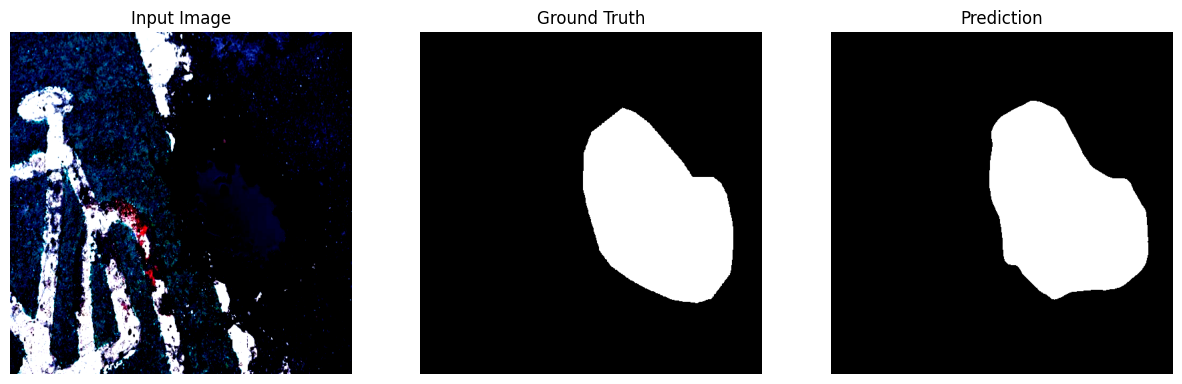

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


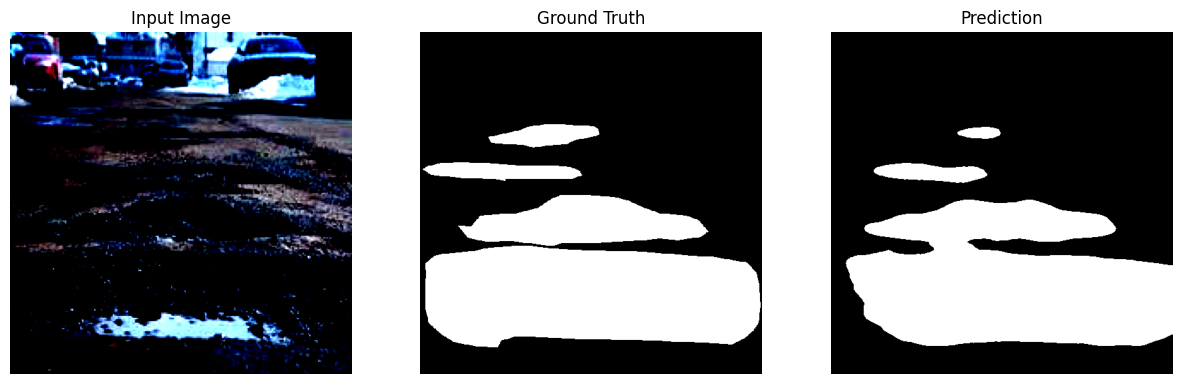

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.6399999].


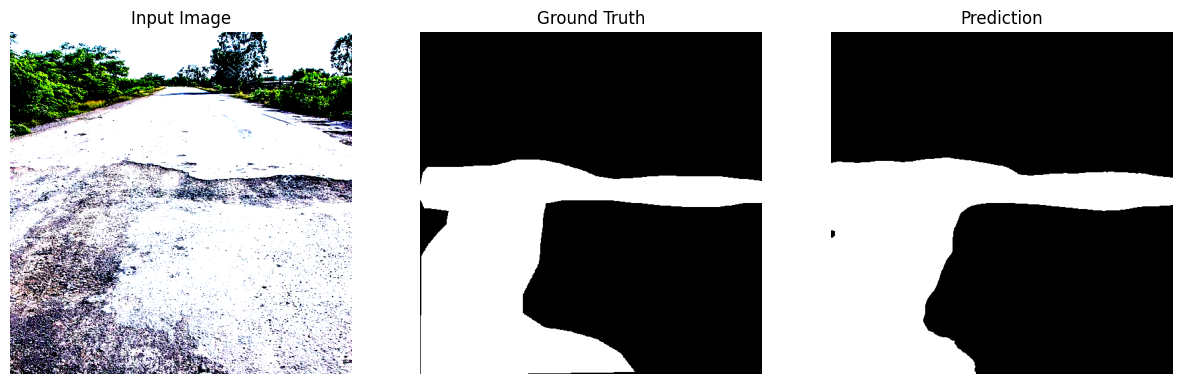

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.3088453].


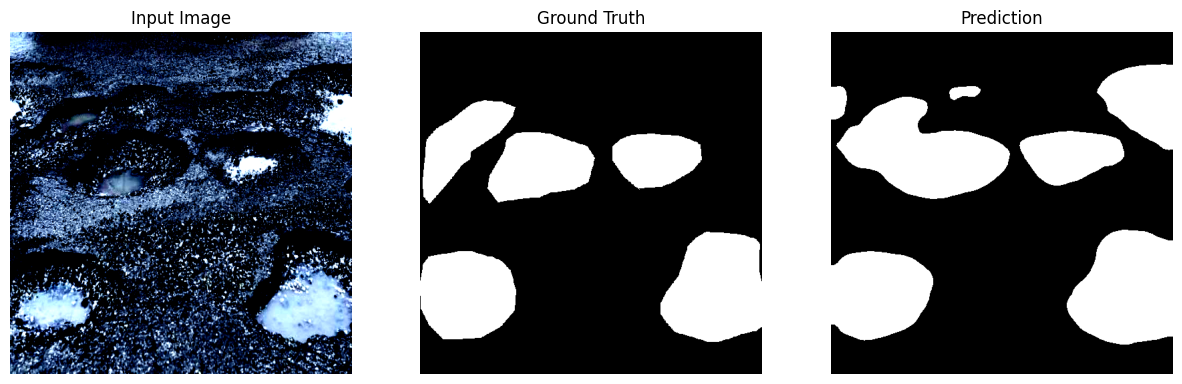

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5702832].


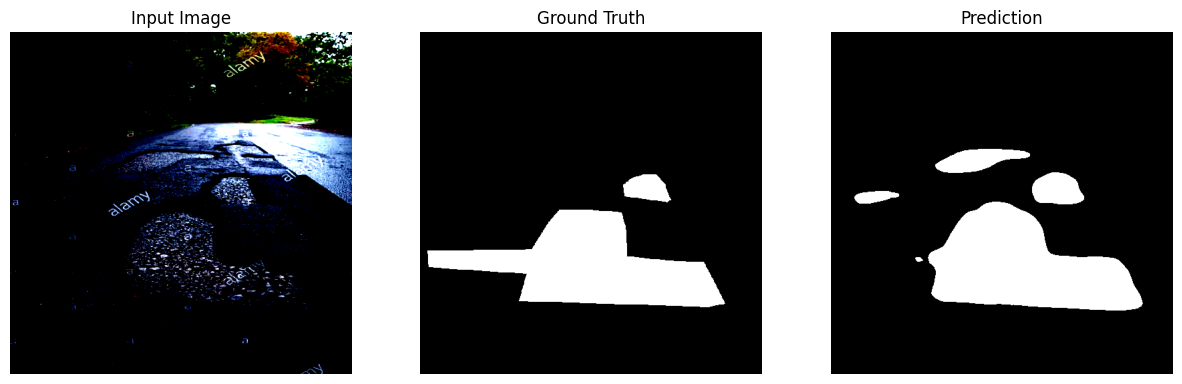

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


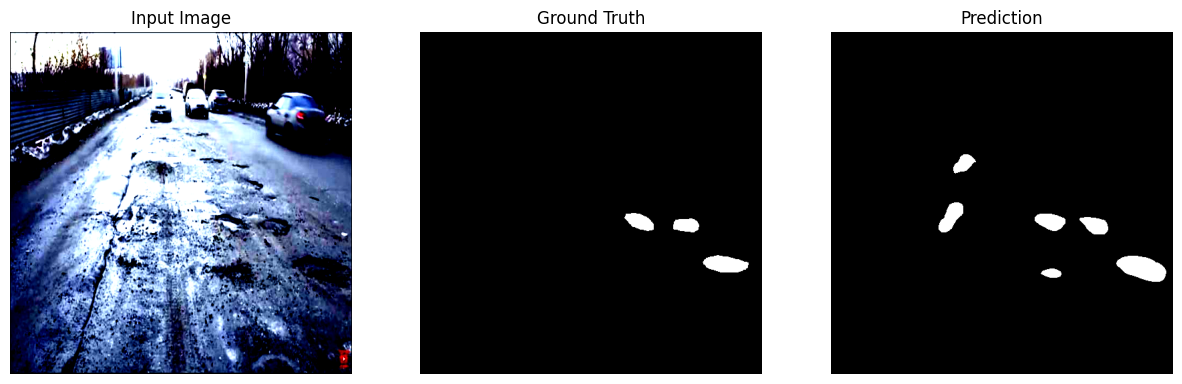

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267832..2.6399999].


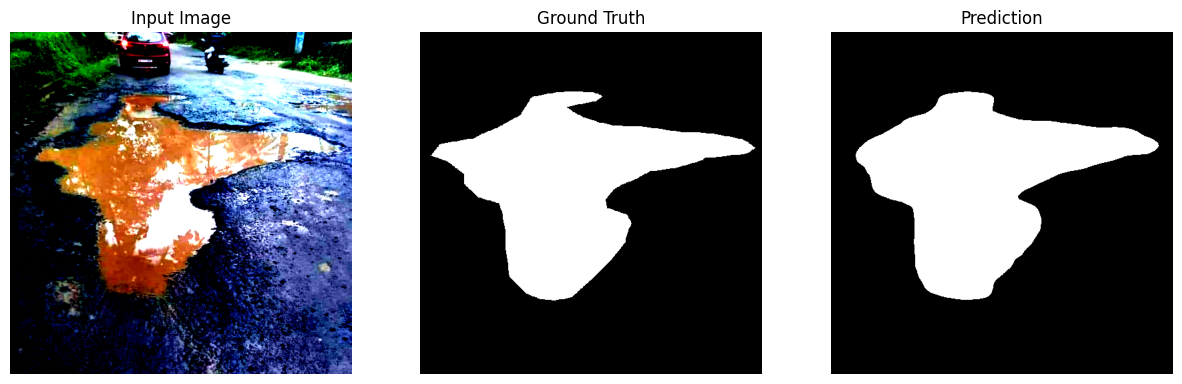

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3879551..2.6399999].


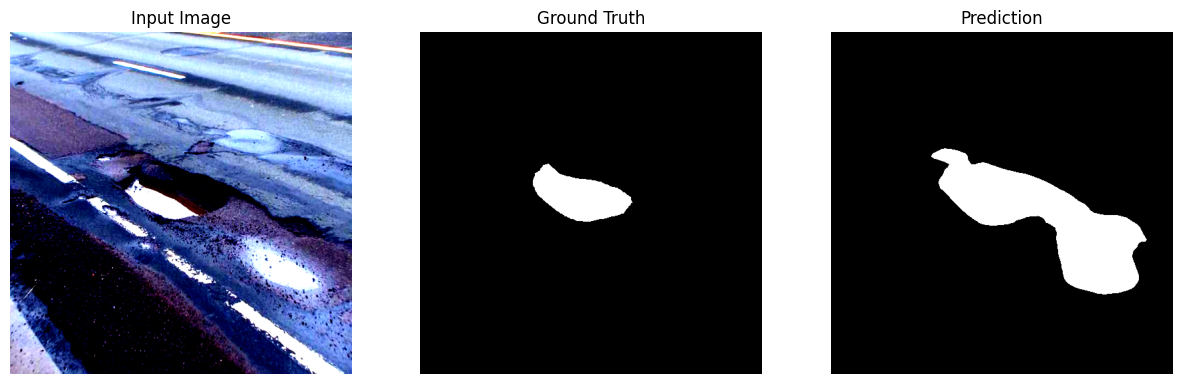

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


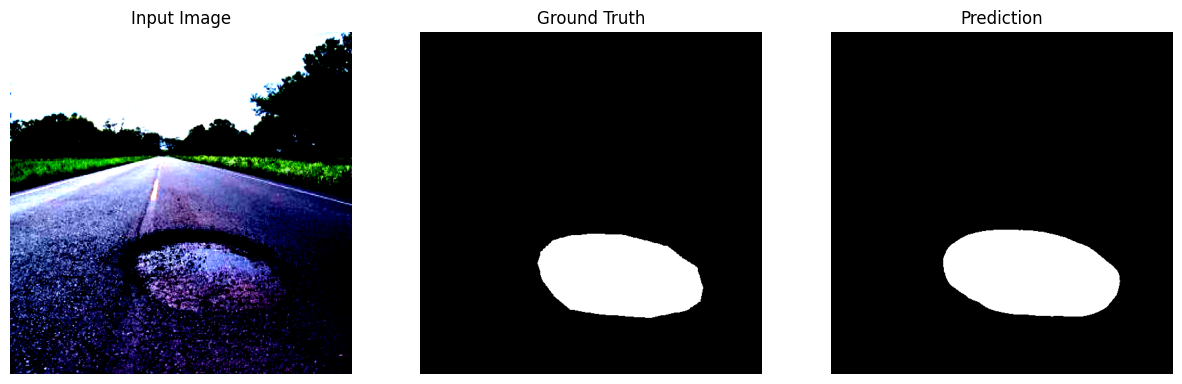

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..2.6399999].


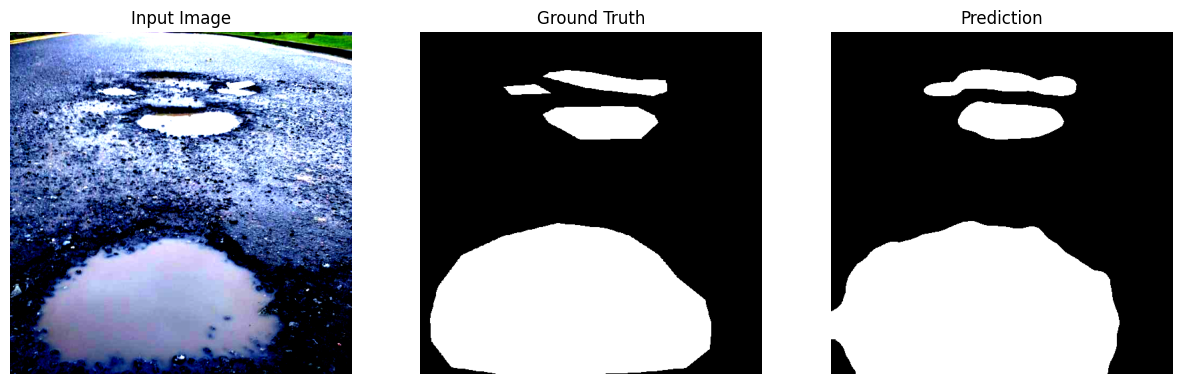

In [24]:
for i in range(20,30):
    visualize_prediction(val_ds, i)

In [25]:
import cv2
import numpy as np

video_path = "/kaggle/input/datasets/farzadnekouei/pothole-image-segmentation-dataset/Pothole_Segmentation_YOLOv8/sample_video.mp4"

cap = cv2.VideoCapture(video_path)

width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    "fast_pothole_prediction.mp4",
    fourcc,
    fps,
    (width,height)
)

In [26]:
while True:

    ret, frame = cap.read()

    if not ret:
        break

    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    resized = cv2.resize(image,(384,384))

    tensor = torch.tensor(resized).permute(2,0,1).float()/255
    tensor = tensor.unsqueeze(0).cuda()

    with torch.no_grad():

        outputs = model(pixel_values=tensor)
        logits = outputs.logits

        logits = torch.nn.functional.interpolate(
            logits,
            size=(512,512),
            mode="bilinear",
            align_corners=False
        )

        pred = torch.sigmoid(logits)
        pred = (pred > 0.35).float()

    mask = pred.squeeze().cpu().numpy()

    mask = cv2.resize(mask,(width,height))

    overlay = frame.copy()

    color_mask = np.zeros_like(frame)
    color_mask[mask>0.5] = [0,0,255]
    
    overlay = cv2.addWeighted(frame,0.8,color_mask,0.5,0)

    out.write(overlay)

In [27]:
cap.release()
out.release()

print("Video saved as pothole_prediction.mp4")

Video saved as pothole_prediction.mp4


In [28]:
from IPython.display import Video

Video("fast_pothole_prediction.mp4")